<a href="https://colab.research.google.com/github/dgonzales1222/greends_avcad_exercises/blob/main/exercise_04/avcad_exer04_dgonzales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advance Visualization of Complex Agro-environmental Data

# **Exercise 4**

Danilo III O. Gonzales (29225) <br>
Master's in Green Data Science

### Exercise Questions

In this exercise you will use the dataset in `EFIplus_medit.zip` to:
1. Using an appropriate visualization, explore how Mean Annual Temperature (Temp_ann) may affect the
presence of Salmo trutta fario (Brown Trout).
2. Check the same effect but now separately for Minho and Tagus catchments and comparing the “effect
sizes”.
3. Test, using both visualization and hypothesis testing methods, if the actual_river_slope is drawn from a
normal distribution.
4. Take 100 samples of 2000 observations of actual_river_slope with replacement, compute the mean for
each sample and plot the resulting histogram of means. Test if these 100 mean values are drawn from a
normal distribution.

In [ ]:
# @title **1. Import Python Packages**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [ ]:
# @title **2. Data Preparation**

# Load data from Github (from exercise 3 folder)
url = 'https://github.com/dgonzales1222/greends_avcad_exercises/raw/main/exercise_03/EFIplus_medit.zip'
df = pd.read_csv(url, compression='zip', sep=';')

print(df)

       Site_code   Latitude  Longitude   Country Catchment_name  Galiza  \
0     ES_01_0002  38.102003  -4.096070     Spain   Guadalquivir       0   
1     ES_02_0001  40.530188  -1.887796     Spain           Tejo       0   
2     ES_02_0002  40.595432  -1.928079     Spain           Tejo       0   
3     ES_02_0003  40.656184  -1.989831     Spain           Tejo       0   
4     ES_02_0004  40.676402  -2.036274     Spain           Tejo       0   
...          ...        ...        ...       ...            ...     ...   
5006      PTVO60  40.641612  -8.325149  Portugal          Vouga       0   
5007      PTVO61  40.729015  -8.098851  Portugal          Vouga       0   
5008      PTVO62  40.727959  -8.107344  Portugal          Vouga       0   
5009      PTVO63  40.817783  -8.224903  Portugal          Vouga       0   
5010      PTVO64  40.794352  -8.255380  Portugal          Vouga       0   

      Subsample  Calib_EFI_Medit  Calib_connect  Calib_hydrol  ...  \
0             1              

In [ ]:
# Clean the Data Set
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all': 'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))

# Drop rows with NaN
df2 = df.dropna()
print(f"Shape after dropna: {df2.shape}")

Shape after dropna: (2822, 154)


In [ ]:
# @title **3. Set Global Plot Settings**

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

### **4. Q1: Using an appropriate visualization, explore how Mean Annual Temperature (Temp_ann) may affect the presence of Salmo trutta fario (Brown Trout).**

To do this, we first need to identify whether brown trout is present or absent in the site. To do this, we will create a column indicating whether the said fish is present or absent in the site.

In [ ]:
# Create presence/absence column for Salmo trutta fario
df2 = df2.copy()
df2['trout_present'] = df2['Salmo trutta fario'].apply(lambda x: 'Present' if x > 0 else 'Absent') # Create a new column. Present if trout is present, absent if not.

# Display output
print(f"\nBrown Trout presence counts:")
print(df2['trout_present'].value_counts())



Brown Trout presence counts:
trout_present
Present    2042
Absent      780
Name: count, dtype: int64


Now that we have this column, we can now do analysis on the effect of mean annual temperature in the presence of Salmo trutta fario or Brown Trout.

In [ ]:
# @title Summary statistics
print("temp_ann by Brown Trout presence:\n")
# Show the summary statistics of grouped sites where trout is present or absent.
print(df2.groupby('trout_present')['temp_ann'].describe().round(2))

temp_ann by Brown Trout presence:

                count   mean   std   min   25%   50%   75%   max
trout_present                                                   
Absent          780.0  15.21  1.55  10.4  14.1  15.4  16.7  17.5
Present        2042.0  12.75  1.56   6.7  11.9  13.0  13.9  17.2


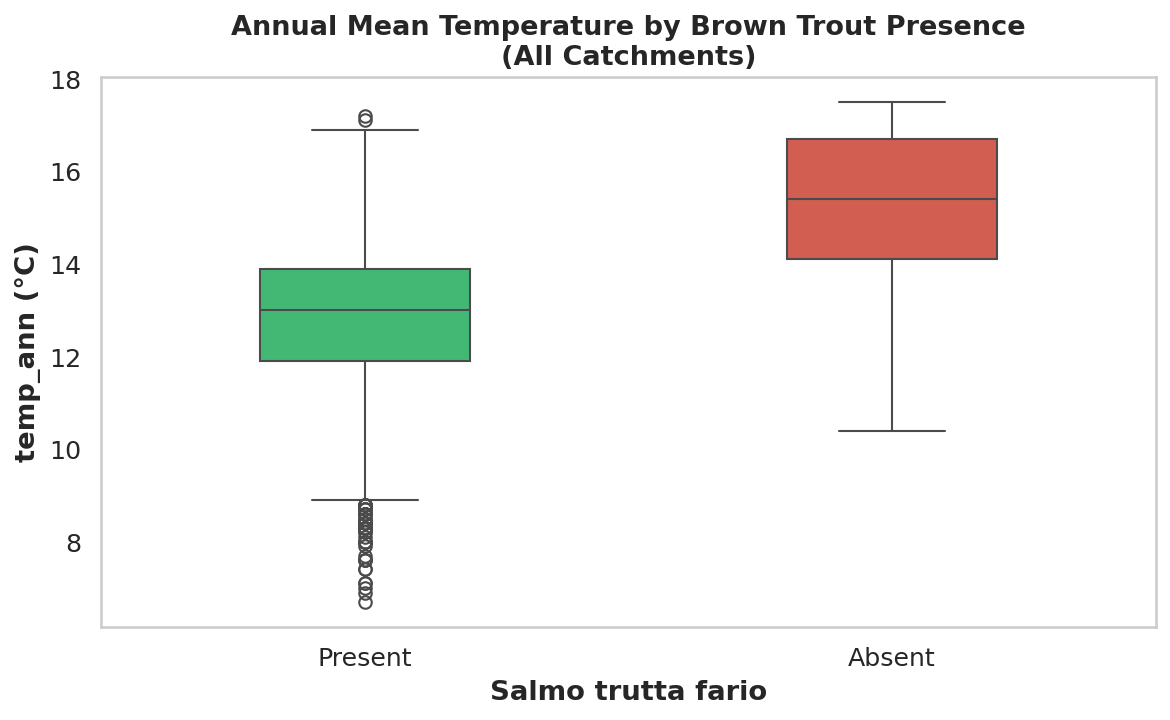

In [ ]:
# @title Boxplot of Mean Temperature by Brown Trout Presence
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='trout_present', y='temp_ann', data=df2, ax=ax,
            hue='trout_present', palette={'Present': '#2ecc71', 'Absent': '#e74c3c'},
            order=['Present', 'Absent'], width=0.4, legend=False)
ax.set_title("Annual Mean Temperature by Brown Trout Presence\n(All Catchments)", fontsize=13)
ax.set_xlabel("Salmo trutta fario")
ax.set_ylabel("temp_ann (°C)")
ax.grid(False)
plt.tight_layout()
plt.show()

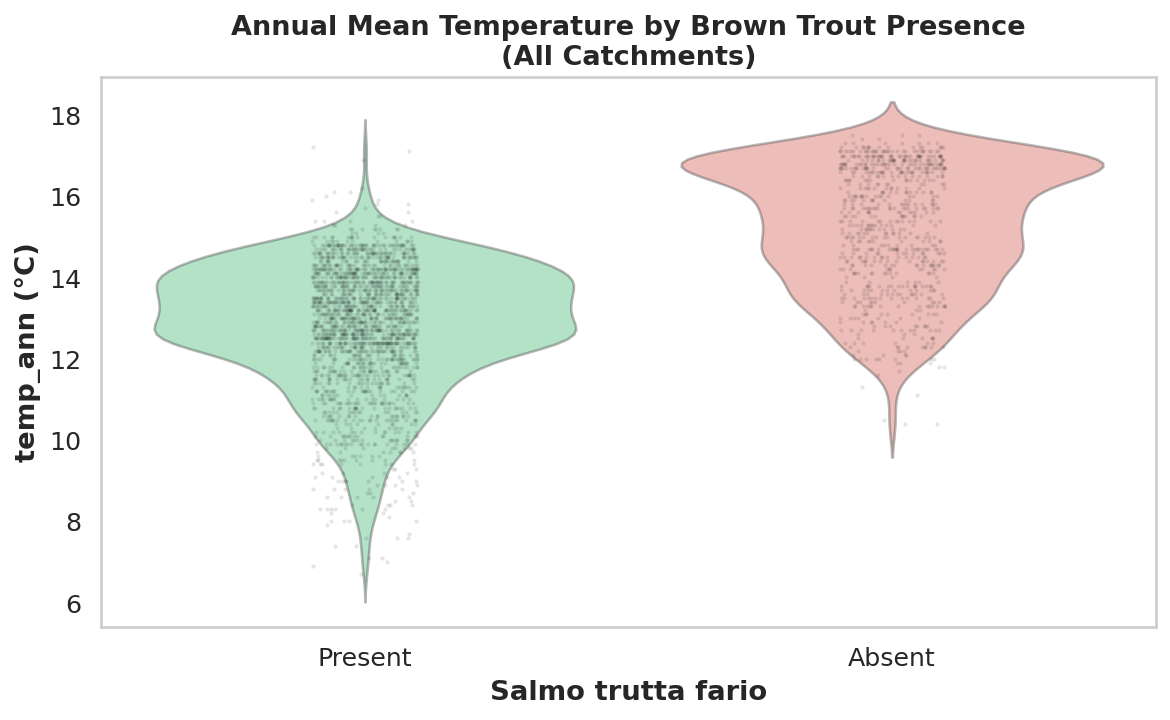

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(x='trout_present', y='temp_ann', data=df2, ax=ax,
               hue='trout_present', palette={'Present': '#2ecc71', 'Absent': '#e74c3c'},
               order=['Present', 'Absent'], inner=None, alpha=0.4, legend=False)
sns.stripplot(x='trout_present', y='temp_ann', data=df2, ax=ax,
              order=['Absent', 'Present'], color='black', alpha=0.1, size=2, jitter=True)
ax.set_title("Annual Mean Temperature by Brown Trout Presence\n(All Catchments)", fontsize=13)
ax.set_xlabel("Salmo trutta fario")
ax.set_ylabel("temp_ann (°C)")
ax.grid(False)
plt.tight_layout()
plt.show()

The boxplot shows Brown Trout is found where annual temperatures are lower (median ≈ 13.0 °C) compared to where it's absent (median ≈ 15.4 °C), with little overlap. The violin plot and data points highlight that the "Present" group clusters around 12–14 °C, while the "Absent" group clusters around 15–17 °C. This suggests Brown Trout prefers cooler waters, with a cutoff near 14–15 °C.

### **5. Q2: Same analysis for Minho and Tagus Catchments**

In [ ]:
df_minho = df2[df2['Catchment_name'] == 'Minho'].copy()
df_tejo = df2[df2['Catchment_name'] == 'Tejo'].copy()

print("Minho catchment:")
print(f"  Total sites: {len(df_minho)}")
print(f"  Trout present: {(df_minho['trout_present'] == 'Present').sum()}")
print(f"  Trout absent:  {(df_minho['trout_present'] == 'Absent').sum()}")
print()
print("Tejo (Tagus) catchment:")
print(f"  Total sites: {len(df_tejo)}")
print(f"  Trout present: {(df_tejo['trout_present'] == 'Present').sum()}")
print(f"  Trout absent:  {(df_tejo['trout_present'] == 'Absent').sum()}")

Minho catchment:
  Total sites: 699
  Trout present: 688
  Trout absent:  11

Tejo (Tagus) catchment:
  Total sites: 235
  Trout present: 46
  Trout absent:  189


/tmp/ipykernel_362/1179870705.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='trout_present', y='temp_ann', data=data, ax=ax,
/tmp/ipykernel_362/1179870705.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='trout_present', y='temp_ann', data=data, ax=ax,


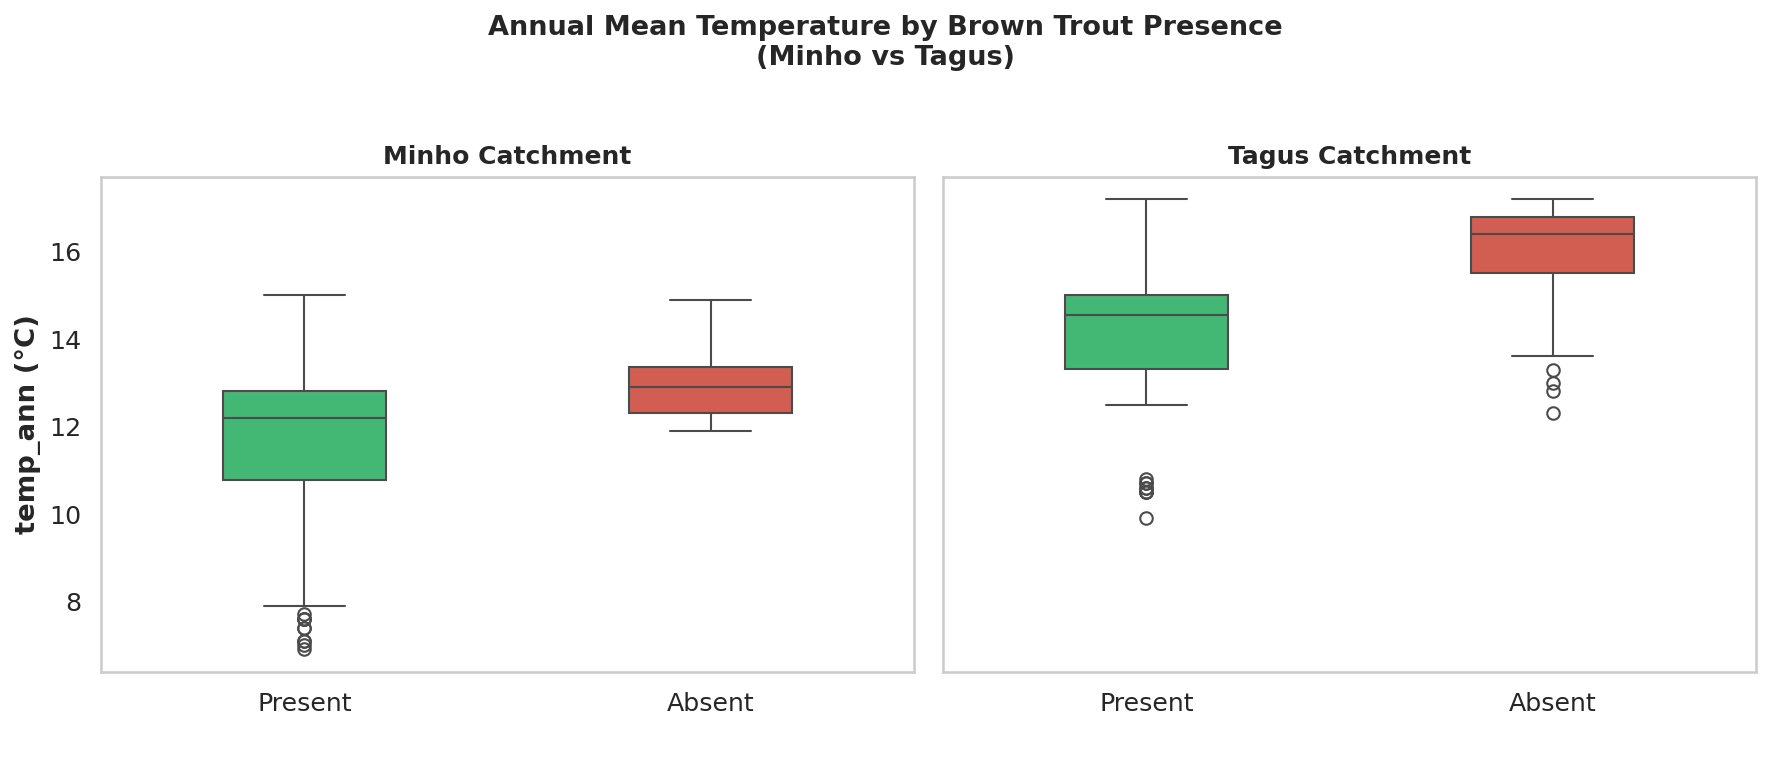

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (name, data) in zip(axes, [('Minho', df_minho), ('Tagus', df_tejo)]):
    sns.boxplot(x='trout_present', y='temp_ann', data=data, ax=ax,
                palette={'Present': '#2ecc71', 'Absent': '#e74c3c'},
                order=['Present', 'Absent'], width=0.4)
    ax.set_title(f"{name} Catchment", fontsize=12)
    ax.set_xlabel(" ")
    ax.set_ylabel("temp_ann (°C)" if ax == axes[0] else "")
    ax.grid(False)

fig.suptitle("Annual Mean Temperature by Brown Trout Presence\n(Minho vs Tagus)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

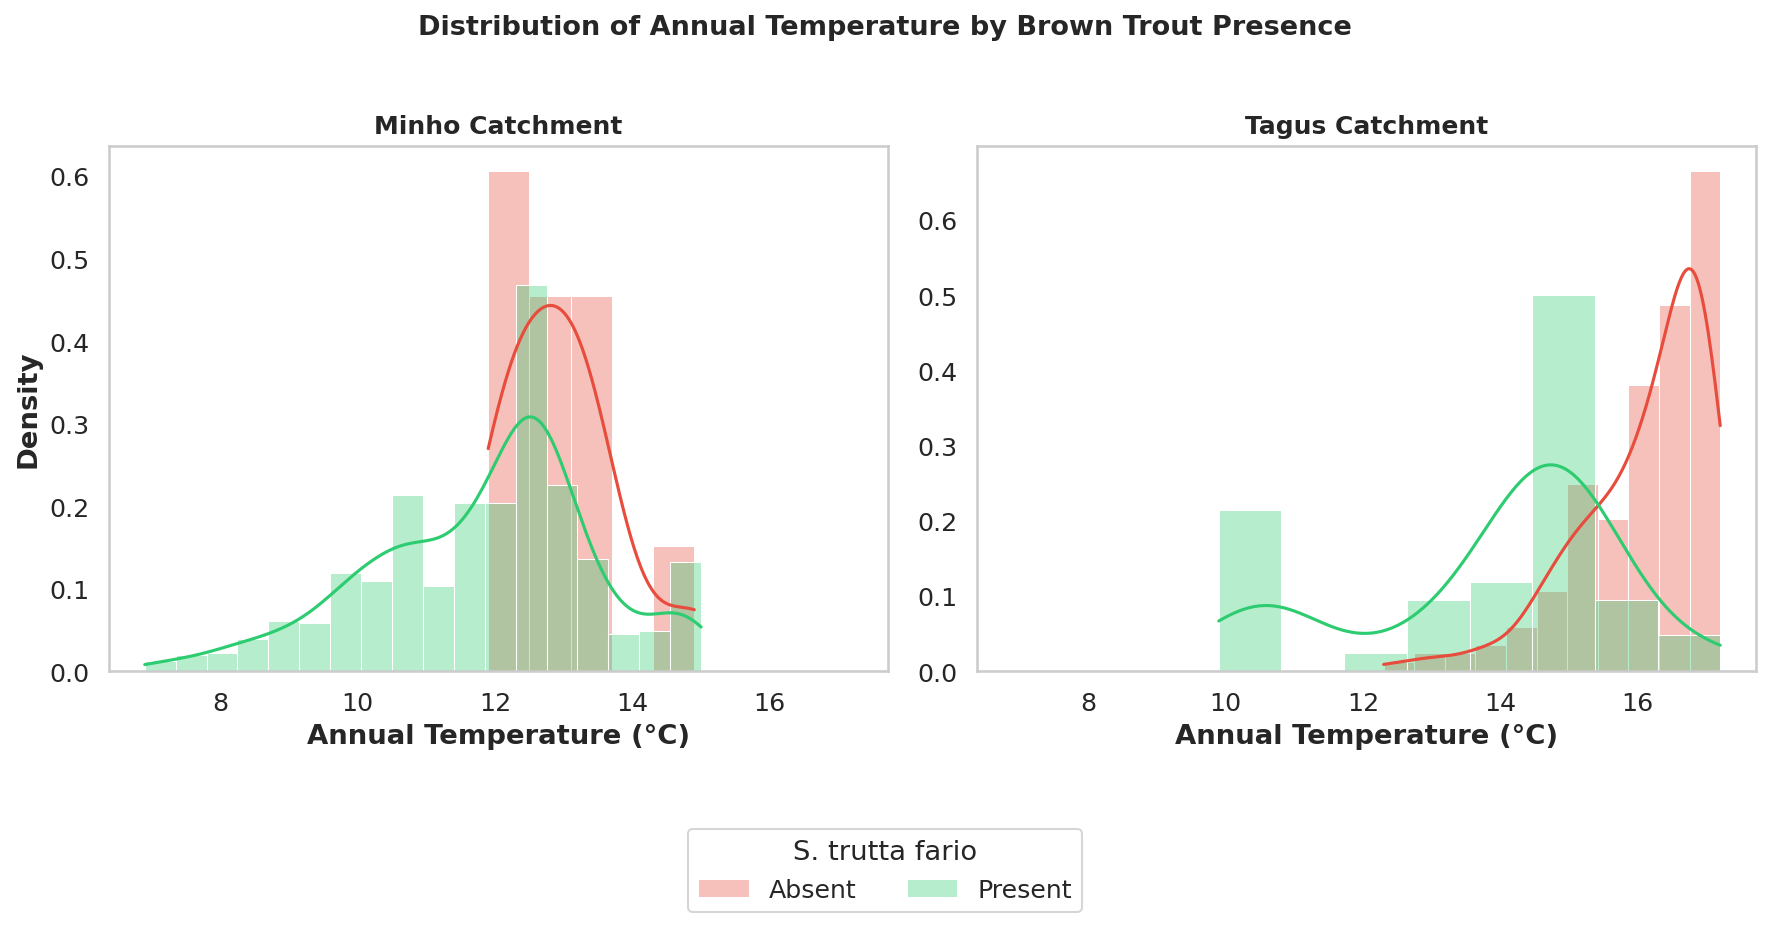

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

for ax, (name, data) in zip(axes, [('Minho', df_minho), ('Tagus', df_tejo)]):
    for group, color in [('Absent', '#e74c3c'), ('Present', '#2ecc71')]:
        subset = data[data['trout_present'] == group]['temp_ann']
        sns.histplot(subset, kde=True, ax=ax, color=color, stat="density",
                     alpha=0.35, edgecolor="white", linewidth=0.5, label=group)
    ax.set_title(f"{name} Catchment", fontsize=12)
    ax.set_xlabel("Annual Temperature (°C)")
    ax.set_ylabel("Density" if ax == axes[0] else "")
    ax.legend().remove()  # Remove individual legends
    ax.grid(False)

fig.suptitle("Distribution of Annual Temperature by Brown Trout Presence", fontsize=13, fontweight='bold', y=1.02)

# Single shared legend below the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="S. trutta fario", loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

In Minho, the temperature difference between trout present and trout absent sites is small. The boxplots largely overlap, with medians around 12.2 °C (present) and 13.0 °C (absent), and the histograms confirm both groups share a similar range (8–15 °C).

In Tegus, the separation is much stronger. Trout present sites cluster around 14–15 °C, while trout-absent sites concentrate around 16–17 °C with minimal overlap.

### **6. Q3: Test, using both visualization and hypothesis testing methods, if the actual_river_slope is drawn from a normal distribution.**

In testing for normality, there are two methods, the first one is via visualization or what you call the Graphical Method (Histogram and Q-Q Plot).

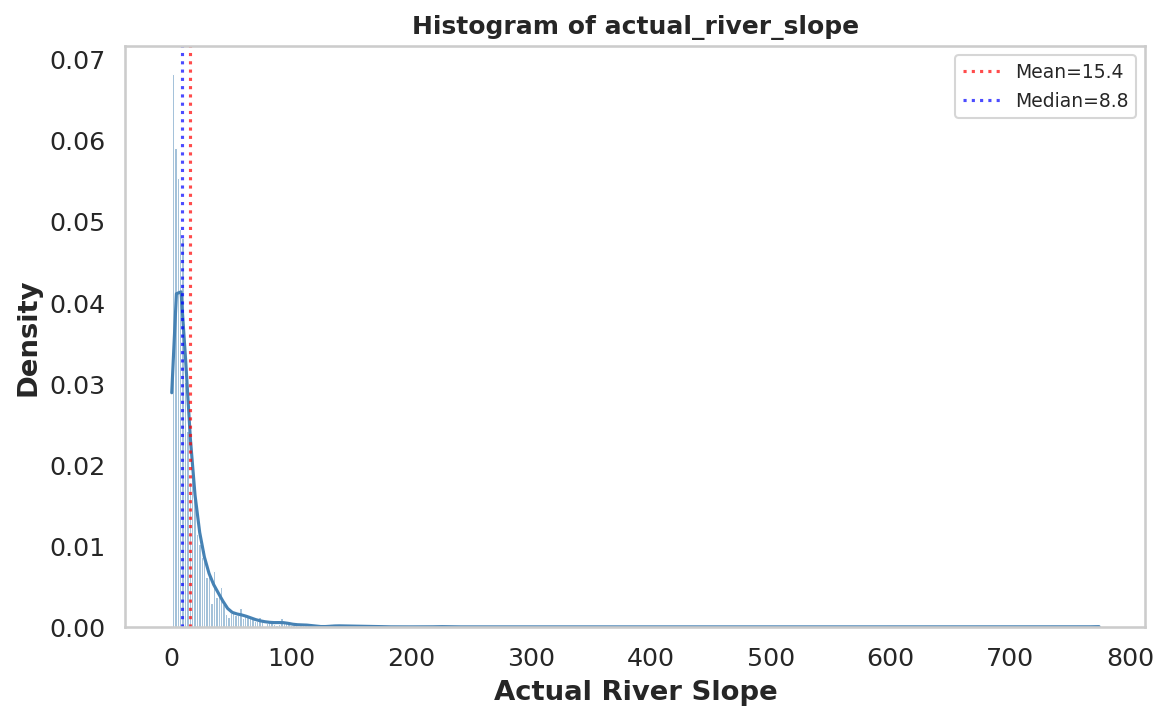

Skewness:  12.7571
Kurtosis:  350.8912


In [ ]:
# @title Histogram with KDE and normal overlay
slope = df2['Actual_river_slope'].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(slope, kde=True, ax=ax, color='steelblue', stat="density",
             alpha=0.5, edgecolor="white", linewidth=0.5)

# Overlay theoretical normal
x = np.linspace(slope.min(), slope.max(), 200)
ax.axvline(slope.mean(), color='red', linestyle=':', alpha=0.7, label=f'Mean={slope.mean():.1f}')
ax.axvline(slope.median(), color='blue', linestyle=':', alpha=0.7, label=f'Median={slope.median():.1f}')
ax.legend(fontsize=9)
ax.set_title("Histogram of actual_river_slope", fontsize=12)
ax.set_xlabel("Actual River Slope")
ax.set_ylabel("Density")
ax.grid(False)
plt.tight_layout()
plt.show()

print(f"Skewness:  {slope.skew():.4f}")
print(f"Kurtosis:  {slope.kurtosis():.4f}")

The histogram shows that the `actual_river_slope` is heavily right skewed. Most values cluster near 0-20 with a long tail extending to 774. Due to this, the mean (15.4) is almost double the median.

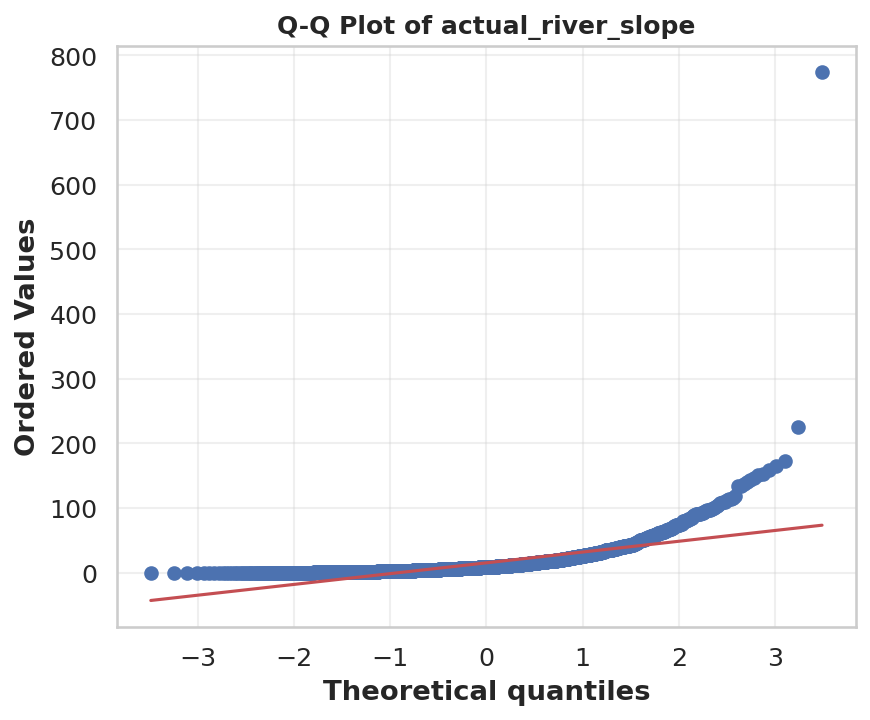

In [ ]:
# Q-Q Plot
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(slope, dist="norm", plot=ax)
ax.set_title("Q-Q Plot of actual_river_slope", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The Q-Q Plot shows that the data does not follow the normal line and follows a curves sharply upward at the right end.

The second one is by performing statistical test and one of the most famous test for normality is the Shapiro Wilk Test for Normality. In the Shapiro Wilk test, the hypothesis are the following:

Null Hypothesis ($H_0):$ The population is normally distributed. <br>
Alternative Hypothesis ($H_A):$ The population is NOT normally distributed.

In this test, we have the following interpretation:

- $value > 0.05$: Fail to reject $H_0$. Data is normally distributed.
- $value \le 0.05$: Reject $H_0$. Data is significantly different from a normal distribution.

In [ ]:
# @title Shapiro-Wilk Test for Normality

stat, p = stats.shapiro(slope)

print(f"Shapiro-Wilk Test")
print(f"  Statistic: {stat:.6f}")
print(f"  p-value:   {p:.6e}")
print(f"\nConclusion: {'Reject H₀ — NOT normal' if p < 0.05 else 'Fail to reject H₀ — consistent with normality'} (α = 0.05)")

Shapiro-Wilk Test
  Statistic: 0.480204
  p-value:   1.039123e-67

Conclusion: Reject H₀ — NOT normal (α = 0.05)


Based on the Shapiro-Wilk test for normality with a test statistic of 0.48 (far from 1.0) and p-value of 1.04e-67, we strongly reject the null hypothesis $H_0$ and conclude hat the `actual_river_slope` is not drawn from a normal distribution.

### **7. Q4: Take 100 samples of 2000 observations of actual_river_slope with replacement, compute the mean for each sample and plot the resulting histogram of means. Test if these 100 mean values are drawn from a normal distribution.**

In [ ]:
# @title Get the list of mean for 100 samples with 2000 observations for `actual_river_slope`
# Random Seed State (42)
np.random.seed(42)

# Calculate the Population Mean
slope_pop = df2['Actual_river_slope'].dropna().values
pop_mean = slope_pop.mean()

# Draw 100 samples of 2000 observations with replacement
n_samples = 100
sample_size = 2000

# For each of the 100 samples: randomly pick 2000 values (with replacement) and compute the mean
sample_means = [np.mean(np.random.choice(slope_pop, size=sample_size, replace=True))
                for _ in range(n_samples)]
sample_means = np.array(sample_means)
print(sample_means)

[16.3716125 15.25447   15.254593  14.8362325 15.575902  14.9257375
 16.6021875 15.542711  16.0790795 14.9082255 14.5228365 15.567351
 14.340067  15.2698    15.666988  14.9017545 16.522002  15.2948945
 15.4191685 15.33575   15.5619215 16.1368465 14.657001  15.947128
 15.123542  15.4177775 16.10552   15.510132  14.7165895 15.006422
 14.635402  15.5991145 15.6795975 16.4708035 15.675772  15.9313805
 15.47376   14.9369155 15.307066  15.4313285 15.834812  15.32797
 14.9640855 14.562458  15.5435575 14.998508  14.929132  15.0326
 15.401514  15.2855065 15.6085245 15.509512  15.0712305 15.534937
 15.1847555 15.63759   15.1611865 14.905359  16.367413  14.8687895
 15.4880805 15.3711075 16.370925  14.709827  16.204068  15.644892
 15.6943095 14.4904395 15.0862825 14.8930315 15.00265   15.2086165
 15.0791975 16.443143  15.4081765 15.277309  15.7021795 16.1763425
 15.708485  14.835728  15.725774  14.7776495 16.2862975 15.229298
 14.512646  15.007675  14.2369485 15.2164905 14.918992  15.6732095
 14.81

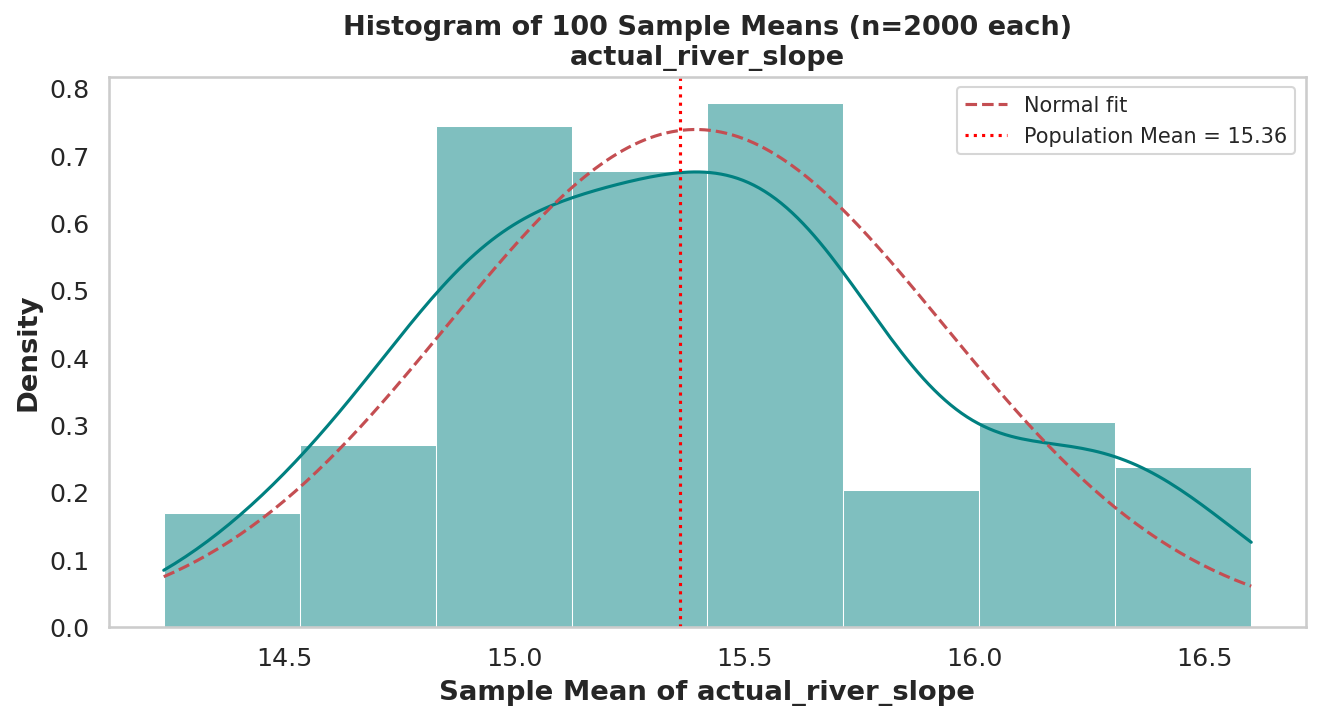

Population mean:              15.3599
Mean of sample means:         15.3938
Std of sample means (obs SE): 0.5401
Theoretical SE (σ/√n):        0.5402


In [ ]:
# @title Create Histogram
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(sample_means, kde=True, ax=ax, color='teal', stat="density",
             alpha=0.5, edgecolor="white", linewidth=0.5)

# Overlay normal fit
x = np.linspace(sample_means.min(), sample_means.max(), 200)
ax.plot(x, stats.norm.pdf(x, sample_means.mean(), sample_means.std()),
        'r--', linewidth=1.5, label='Normal fit')
ax.axvline(pop_mean, color='red', linestyle=':', linewidth=1.5,
           label=f'Population Mean = {pop_mean:.2f}')

ax.set_title("Histogram of 100 Sample Means (n=2000 each)\nactual_river_slope", fontsize=13)
ax.set_xlabel("Sample Mean of actual_river_slope")
ax.set_ylabel("Density")
ax.legend(fontsize=10)
ax.grid(False)
plt.tight_layout()
plt.show()

print(f"Population mean:              {pop_mean:.4f}")
print(f"Mean of sample means:         {sample_means.mean():.4f}")
print(f"Std of sample means (obs SE): {sample_means.std():.4f}")
print(f"Theoretical SE (σ/√n):        {slope_pop.std() / np.sqrt(sample_size):.4f}")

The histogram of 100 sample means with n=2000 each forms an approximately bell-shaped distribution centered around the mean of 15.36.

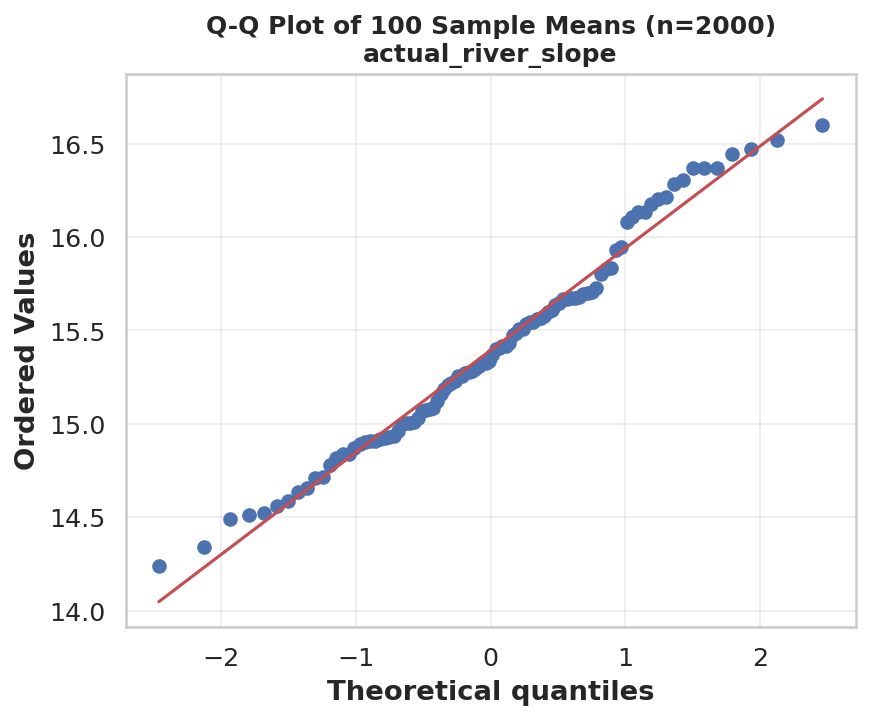

In [ ]:
# Q-Q Plot
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(sample_means, dist="norm", plot=ax)
ax.set_title("Q-Q Plot of 100 Sample Means (n=2000)\nactual_river_slope", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
The Q-Q plot supports the Histogram since most of the points follow the normal line closely with minor deviation at the tails.

In [ ]:
# @title Test for Normality
stat_sw, p_sw = stats.shapiro(sample_means)
stat_da, p_da = stats.normaltest(sample_means)
stat_ks, p_ks = stats.kstest(sample_means, 'norm', args=(sample_means.mean(), sample_means.std()))

print(f"{'Test':<25} {'Statistic':>12} {'p-value':>12} {'Normal?':>10}")
print("-" * 61)
for name, stat, p in [('Shapiro-Wilk', stat_sw, p_sw),
                       ("D'Agostino-Pearson", stat_da, p_da),
                       ('Kolmogorov-Smirnov', stat_ks, p_ks)]:
    normal = 'Yes' if p > 0.05 else 'No'
    print(f"{name:<25} {stat:>12.6f} {p:>12.6e} {normal:>10}")

Test                         Statistic      p-value    Normal?
-------------------------------------------------------------
Shapiro-Wilk                  0.980701 1.506954e-01        Yes
D'Agostino-Pearson            2.638743 2.673033e-01        Yes
Kolmogorov-Smirnov            0.060045 8.422433e-01        Yes


All three normality tests (Shapiro-Wilk, D'Agostino-Pearson, Kolmogorov-Smirnov) gave p-values above 0.05, so we conclude the sample means are normally distributed.

Applying the concept of `Central Limit Theorem`, the distribution of the sample means becomes approximately normal when the sample size is large enough.

We can also observe that as you increase the sample size, the sample mean converges to the population mean (`Law of Large Numbers`).